In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# Loading the dataset

In [ ]:
train_images = np.load('/content/train_images.npy')
train_labels = np.load('/content/train_labels.npy')
test_images = np.load('/content/test_images.npy')
test_labels = np.load('/content/test_labels.npy')

train_images.shape
train_images[0].shape
test_images.shape

(10000, 28, 28)

In [ ]:
train_images[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170,
        253, 253, 253, 253, 253, 225, 172, 253, 242, 195,  64,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  49, 238, 253, 253, 253, 253,
        253, 253, 253, 253, 251,  93,  82,  82,  56,  39,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 219, 253, 253, 253, 253,
        253, 198, 182, 247, 241,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  80, 156, 107, 253, 253,
        205,  11,   0,  43, 154,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  14,   1, 154, 253,
         90,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 139, 253,
        190,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190,
        253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35,
        241, 225, 160, 108,   1,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         81, 240, 253, 253, 119,  25,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  45, 186, 253, 253, 150,  27,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  16,  93, 252, 253, 187,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 249, 253, 249,  64,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  46, 130, 183, 253, 253, 207,   2,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  39,
        148, 229, 253, 253, 253, 250, 182,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24, 114, 221,
        253, 253, 253, 253, 201,  78,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  23,  66, 213, 253, 253,
        253, 253, 198,  81,   2,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  18, 171, 219, 253, 253, 253, 253,
        195,  80,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  55, 172, 226, 253, 253, 253, 253, 244, 133,
         11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 253, 25

In [ ]:
train_labels[0]

np.uint8(5)

In [ ]:
# tensordataset example

features = torch.tensor([[1.0,2.0], [3.0,4.0] , [5.0,6.0]])
labels = torch.tensor([0,1,0])

dataset = TensorDataset(features, labels)

dataset[1]

(tensor([3., 4.]), tensor(1))

In [ ]:
# dataloader

dataloader = DataLoader (dataset , batch_size = 2, shuffle = True)

for batch in dataloader :
  features , label = batch
  print("feature :", features)
  print("label :", label)

feature : tensor([[1., 2.],
        [3., 4.]])
label : tensor([0, 1])
feature : tensor([[5., 6.]])
label : tensor([0])


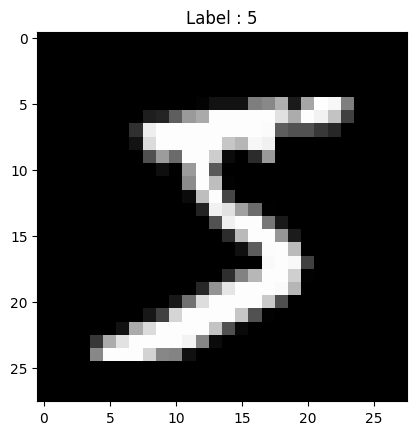

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(train_images[0] , cmap ='gray')
plt.title(f'Label : {train_labels[0]}')

plt.show()


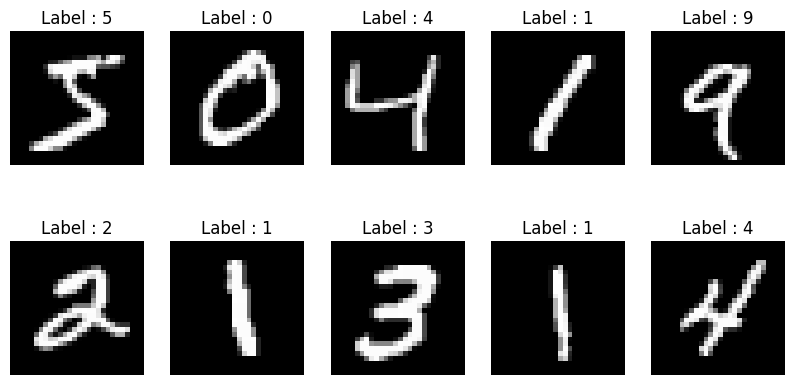

In [ ]:
fig , axes = plt.subplots(2, 5 , figsize=(10,5))
axes = axes.flatten()

for i in range(10):
  axes[i].imshow(train_images[i] , cmap='gray')
  axes[i].set_title(f'Label : {train_labels[i]}')
  axes[i].axis('off')


plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

X_train_np , X_val_np , y_train_np , y_val_np = train_test_split( train_images, train_labels , test_size=0.1 , random_state=42)


X_train = torch.tensor(X_train_np , dtype = torch.float32)
y_train = torch.tensor(y_train_np , dtype = torch.long)

X_val = torch.tensor(X_val_np, dtype = torch.float32)
y_val = torch.tensor(y_val_np , dtype = torch.long)


X_test = torch.tensor(test_images , dtype = torch.float32)
y_test = torch.tensor(test_labels ,dtype = torch.long )


In [ ]:
X_train.shape

torch.Size([54000, 28, 28])

In [ ]:
train_dataset = TensorDataset(X_train,y_train)
val_dataset = TensorDataset(X_val,y_val)
test_dataset = TensorDataset(X_test,y_test)


train_loader = DataLoader(train_dataset ,batch_size=64 , shuffle = True)
val_loader = DataLoader(val_dataset ,batch_size=64 , shuffle = False)
test_loader = DataLoader(test_dataset ,batch_size=64 , shuffle = False)


In [ ]:
class DigitClassificationModel(nn.Module):
  def __init__(self , input_size, num_classes):
    super().__init__()

    self.network = nn.Sequential(
        nn.Flatten(),
        nn.Linear(input_size , 128 ), # 1st layer = 128 ta neuron
        nn.ReLU(),
        nn.Linear(128,64), # 2nd layer e 64 ta neuron
        nn.ReLU(),
        nn.Linear(64,num_classes) #Output layer
    )

  def forward(self , features):
    output = self.network(features)
    return output


In [ ]:
model =  DigitClassificationModel(input_size = 28*28 , num_classes=10)
print(model)

DigitClassificationModel(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr= 0.01)

In [ ]:
epochs = 10


for epoch in range(epochs):

  running_loss = 0.0

  for images,labels in train_loader :
    optimizer.zero_grad()

    outputs = model(images)

    loss = criterion(outputs,labels )

    loss.backward()

    optimizer.step()

    running_loss+= loss.item()

  val_loss = 0.0

  with torch.no_grad():
    for images,labels in val_loader :
      outputs = model(images)
      loss = criterion(outputs,labels)
      val_loss+= loss.item()

  print(f'Epoch {epoch+1}/ {epochs} | Train Loss : {running_loss:.4f} | Validation Loss: {val_loss:.4f}'
  )


Epoch 1/ 10 | Train Loss : 2061.7122 | Validation Loss: 163.8478
Epoch 2/ 10 | Train Loss : 1400.1277 | Validation Loss: 153.8196
Epoch 3/ 10 | Train Loss : 1268.8382 | Validation Loss: 129.2842
Epoch 4/ 10 | Train Loss : 1277.1609 | Validation Loss: 163.6212
Epoch 5/ 10 | Train Loss : 1140.4457 | Validation Loss: 112.9578
Epoch 6/ 10 | Train Loss : 930.1955 | Validation Loss: 88.3525
Epoch 7/ 10 | Train Loss : 844.4813 | Validation Loss: 96.5635
Epoch 8/ 10 | Train Loss : 813.1705 | Validation Loss: 86.4046
Epoch 9/ 10 | Train Loss : 721.1042 | Validation Loss: 72.5855
Epoch 10/ 10 | Train Loss : 580.0466 | Validation Loss: 58.8020


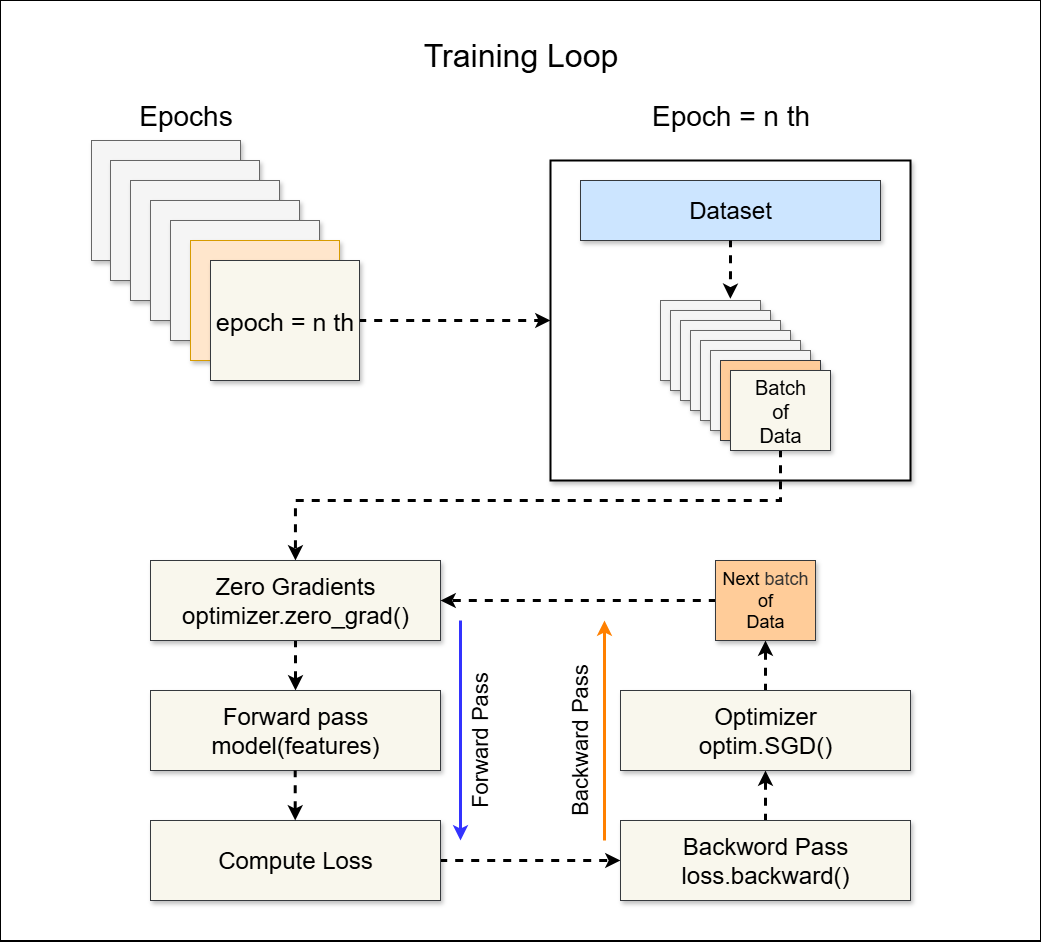

In [ ]:
with torch.no_grad():
  y_pred_prob = model(X_test)


y_pred_prob.shape

y_pred = torch.argmax(y_pred_prob ,dim = 1)


print("Prediction", y_pred[:10])
print("Actual : ,", y_test[:10])


Prediction tensor([7, 2, 1, 0, 4, 1, 4, 9, 6, 7])
Actual : , tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])


HW: Accuracy Report , Confusion Matrix